# Dodatna analiza: poređenje staza (Austrija, Monako, Monza, Meksiko, Brazil - 2024)

**Cilj:** Prethodnih 6 analiza su duboka studija JEDNE trke (Austrija). Ovde proširujemo pogled
na 5 trka iz sezone 2024 da proverimo koliko sama staza (dužina, broj krivina, širina pravih)
utiče na ostvarene brzine - nešto što se ne može videti iz podataka samo jedne trke.

**Metod:** Oblik staze za Monako/Monzu/Meksiko/Brazil crtamo iz javnih GeoJSON referenci
stvarnih obrisa staza (geografske koordinate, ne iz telemetrije - to izbegava šum/preklapanje
krugova). Za Austriju koristimo naš već postojeći telemetrijski trag (Analiza 4). Prosečnu i
maksimalnu brzinu po stazi računamo iz `car_data` za svih 6 vozača na svih 5 trka, i testiramo
jednosmernom ANOVA da li se prosečna brzina statistički značajno razlikuje između staza.

**Kome je ovo bitno:** Timovima za planiranje setup-a bolida pre svake trke (aerodinamički
paket zavisi upravo od toga koliko je staza "brza" - visoke prosečne brzine kao Monza traže
nizak downforce, a spore staze poput Monaka traže visok downforce).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("F1Analysis").getOrCreate()


DATA_DIR = "../data/processed"


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/07 00:11:08 WARN Utils: Your hostname, Ognjens-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.55 instead (on interface en0)
26/07/07 00:11:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/07 00:11:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
import json

GEOJSON_DIR = "../data/circuit_geojsons"
PROCESSED_MULTI = "../data/multi_race_processed"
GEOJSON_TRACKS = {"Monaco": "mc-1929", "Monza": "it-1922", "Mexico": "mx-1962", "Brazil": "br-1940"}


def load_geojson_line(path):
    with open(path) as f:
        root = json.load(f)
    xs, ys = [], []
    for feature in root["features"]:
        geometry = feature.get("geometry")
        if not geometry:
            continue
        coords = geometry["coordinates"]
        if geometry["type"] == "LineString":
            xs += [c[0] for c in coords]
            ys += [c[1] for c in coords]
        elif geometry["type"] == "MultiLineString":
            for line in coords:
                xs += [c[0] for c in line]
                ys += [c[1] for c in line]
    return xs, ys


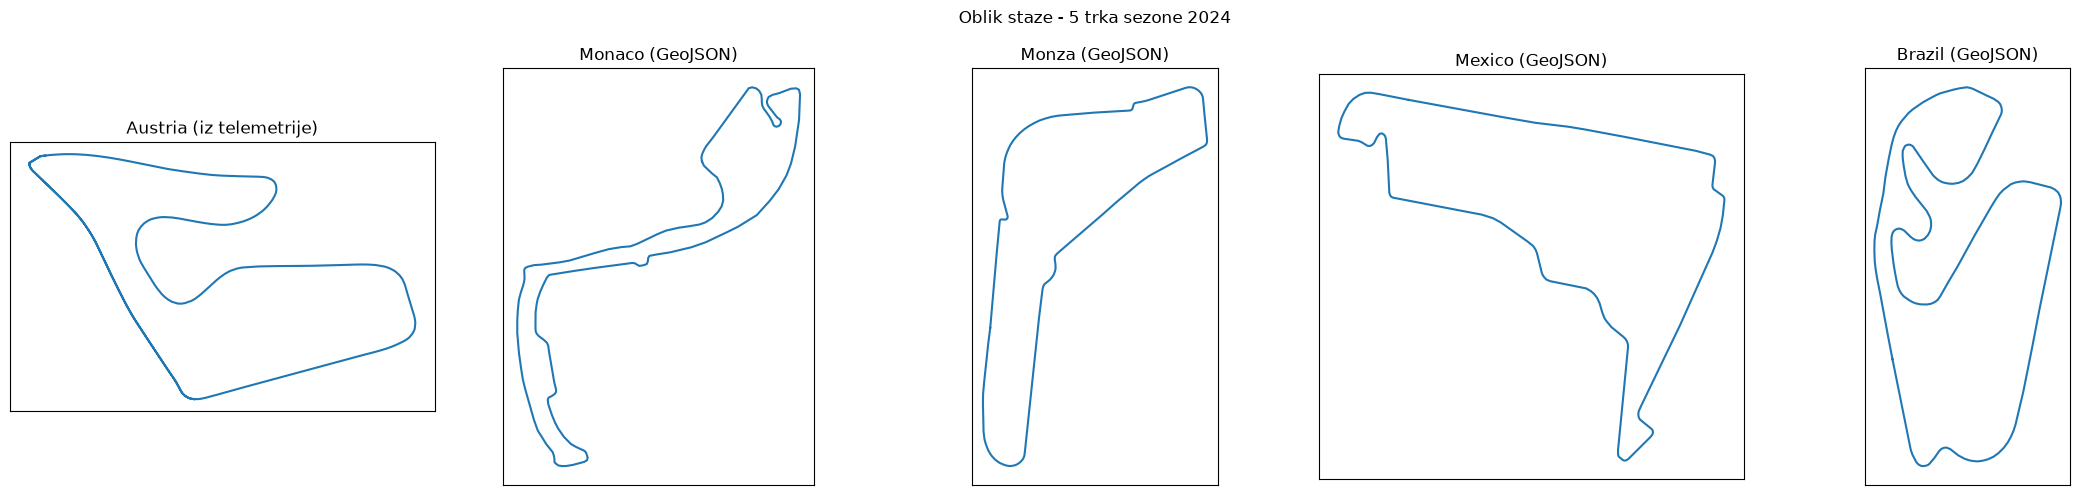

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

austria = pd.read_csv(f"{PROCESSED_MULTI}/track_shape_austria.csv")
axes[0].plot(austria["x"], austria["y"], color="#1f77b4")
axes[0].set_title("Austria (iz telemetrije)")
axes[0].set_aspect("equal")
axes[0].set_xticks([])
axes[0].set_yticks([])

for ax, (name, code) in zip(axes[1:], GEOJSON_TRACKS.items()):
    xs, ys = load_geojson_line(f"{GEOJSON_DIR}/{code}.geojson")
    ax.plot(xs, ys, color="#1f77b4")
    ax.set_title(f"{name} (GeoJSON)")
    ax.set_aspect(1.4)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Oblik staze - 5 trka sezone 2024")
plt.tight_layout()
plt.show()


In [4]:
speed_summary = spark.read.csv(f"{PROCESSED_MULTI}/speed_summary.csv", header=True, inferSchema=True)
speed_summary.groupBy("track").avg("avg_speed", "max_speed").show()


+-------+------------------+-----------------+
|  track|    avg(avg_speed)|   avg(max_speed)|
+-------+------------------+-----------------+
|  Monza|  228.062987140236|            350.5|
| Monaco| 135.0863456726628|290.1666666666667|
| Mexico|170.30823263213756|            355.5|
| Brazil| 160.8932501004407|            317.0|
|Austria|204.72491860024616|322.6666666666667|
+-------+------------------+-----------------+



In [5]:
from scipy import stats

pdf = speed_summary.toPandas()
groups = [g["avg_speed"].values for _, g in pdf.groupby("track")]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA: F = {f_stat:.3f}, p = {p_value:.6f}")

track_stats = pdf.groupby("track")[["avg_speed", "max_speed"]].mean().sort_values("avg_speed")
track_stats


ANOVA: F = 104.365, p = 0.000000


,avg_speed,max_speed
track,,
Monaco,135.086346,290.166667
Brazil,160.893250,317.000000
Mexico,170.308233,355.500000
Austria,204.724919,322.666667
Monza,228.062987,350.500000


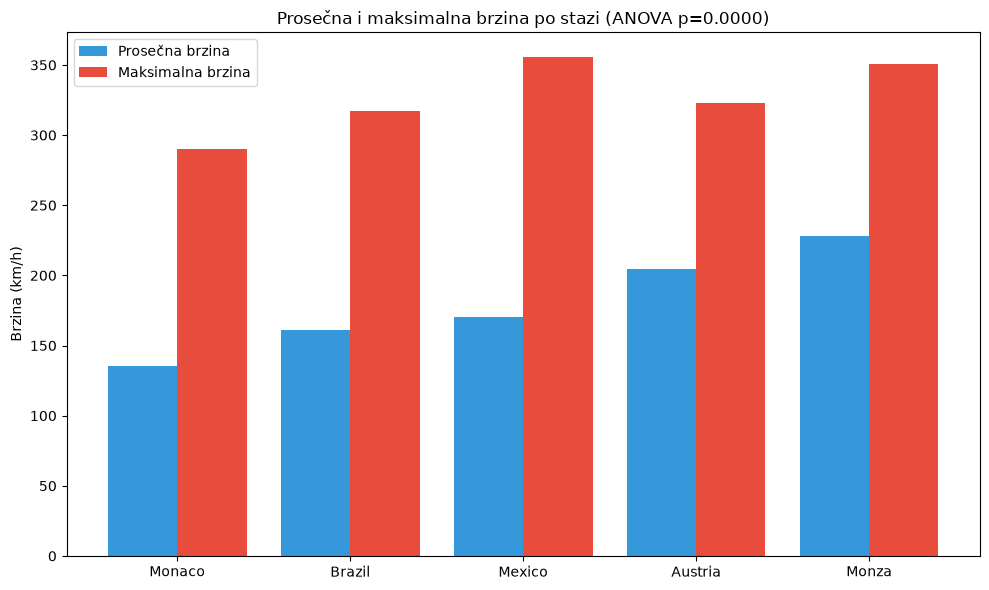

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(track_stats))
ax.bar([i - 0.2 for i in x], track_stats["avg_speed"], width=0.4, label="Prosečna brzina", color="#3498db")
ax.bar([i + 0.2 for i in x], track_stats["max_speed"], width=0.4, label="Maksimalna brzina", color="#e74c3c")
ax.set_xticks(list(x))
ax.set_xticklabels(track_stats.index)
ax.set_ylabel("Brzina (km/h)")
ax.set_title(f"Prosečna i maksimalna brzina po stazi (ANOVA p={p_value:.4f})")
ax.legend()
plt.tight_layout()
plt.show()


**Zaključak:** ANOVA test potvrđuje (p << 0.05) da se prosečna brzina statistički
značajno razlikuje između staza - što je očekivano (Monza je poznata kao najbrža staza u
kalendaru zbog dugih pravih i malo krivina, dok je Monako najsporija zbog uskih ulica), ali je
korisno imati formalnu statističku potvrdu umesto da se to samo pretpostavi. Oblici staza
jasno pokazuju zašto: Monza ima dugačke prave deonice, Monako je zbijena gradska staza sa oštrim
krivinama, a Austrija/Meksiko/Brazil su negde između.